# Yo-Yo-Math plotting functions

A collection of utilities used to generate the plots in Yo-Yo-Math

![](./cover.png){width="30%"}

## Number lines and Cartesian planes

Utilities to draw number lines and Cartesian planes

In [6]:
import logging
import warnings
import matplotlib.font_manager

# Suppress matplotlib font warnings
logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings('ignore')

# Render matplotlib figures as SVG instead of PNG
%config InlineBackend.figure_formats = ['svg']

from yoyo_plots.common import display_vector, VectorDisplay
from yoyo_plots.number_line import NumberLine, CircularNumberLine, CartesianPlane

# Override _repr_html_ so GitHub can render figures.
# This version returns a static SVG wrapped in HTML instead.
# The behavior implemented in common.py is intended for a Quarto document
def _static_html(self):
    svg = self._repr_svg_()
    if svg:
        return svg
    if hasattr(self.fig, "to_image"):
        return self.fig.to_image(format="svg").decode("utf-8")
    return None

VectorDisplay._repr_html_ = _static_html

In [2]:
segment = {"color": "blue", "thickness": 3, "arrow": True}

fig = (NumberLine(-5, 5)
 .add_markers({0: "red"}, marker_size=0.2)
 .add_segments({i: segment for i in [-2, 3, 4, 5]}, segment_width=5)
)
display_vector(fig)

In [3]:
image = "./images/1f998_kangaroo_flipped.svg"
freq = 2
arc = {"color": "fuchsia", "len": freq, "text": f"+{freq}"}

fig = (NumberLine(0, 20, tick_frequency=2)
 .add_tick_icons({0: image})
 .add_arcs({0: arc, 2: arc})
)
display_vector(fig)

In [4]:
segment = {"color": "purple", "thickness": 3, "arrow": True}

circ = (CircularNumberLine(xmin=0, xmax=12, tick_distance=5, font_size=20)
 .add_segments({i: segment for i in [4, 8]})
 .add_center_image("./images/alien.svg", size=4.0)
 .add_tick_icons({3: "./images/alien.svg", 9: "./images/1f6b2_bike.svg"}, tick_icon_size=2.0)
 .add_boxes(box_size=3, box_labels={"box1": "1", "box2": "+", "box3": "2", "box4": 3})
 .build()
)

display_vector(circ)

In [5]:
cartesian = (CartesianPlane(xmin=-11, xmax=3, ymin=-5, ymax=5)
 .add_markers({
     (3, 4): {"color": "red", "draw_lines": True, "show_coords": True},
     (-2, -3): {"color": "blue", "draw_lines": False},
     (1, -2): {"color": "purple"}
 })
 .add_manhattan_lines({
     ((-2, -3), (1, -2)): {"color": "green", "path": "x_first", "dash": "solid"},
 })
 .add_icons({
     (-4, 2): {"image": "./images/alien.svg", "color": "orange", "draw_lines": True, "show_coords": True}
 })
)

display_vector(cartesian)

In [6]:
areas_fig = (CartesianPlane(xmin=-1, xmax=6, ymin=-1, ymax=5)
 .add_areas([
     {"x0": 1, "y0": 0, "x1": 4, "y1": 3, "color": "steelblue",
      "alpha": 0.3, "show_label": True},
     {"x0": 0, "y0": 0, "x1": 2, "y1": 2, "color": "salmon",
      "alpha": 0.4, "show_label": True},
 ])
)

display_vector(areas_fig)

## Functions and areas

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

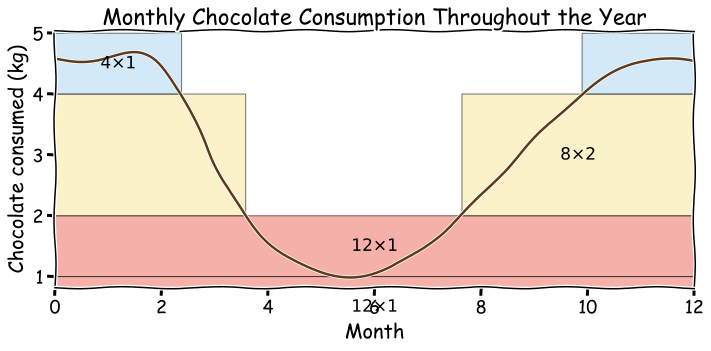

In [1]:
import numpy as np
from yoyo_plots.functions import FunctionPlot
from yoyo_plots.common import display_vector

# ── Chocolate consumption curve (kg/month) ─────────────────────────────────
months = np.linspace(0, 12, 400)
chocolate = (
    2.8
    + 1.8 * np.cos(2 * np.pi * (months - 11.5) / 12)   # winter peak
    + 1.2 * np.exp(-((months - 2) ** 2) / 1.2)          # Valentine's bump
)

# ── Colors keyed by integer height ────────────────────────────────────────
height_colors = {
    1: "#aed6f1",   # light blue
    2: "#82e0aa",   # mint green
    3: "#f9e79f",   # light yellow
    4: "#f0b27a",   # peach
    5: "#ec7063",   # salmon
    6: "#c39bd3",   # lavender
}

# ── Rectangles with varying widths ────────────────────────────────────────
groups = [
    (0, 1),    # January
    (1, 2),    # February  (Valentine's peak – kept alone)
    (2, 4),    # March + April
    (4, 5),    # May
    (5, 8),    # June – August (summer, low season)
    (8, 9),    # September
    (9, 11),   # October + November
    (11, 12),  # December (Christmas peak – kept alone)
]

rectangles = []
for start, end in groups:
    mid = 0.5 * (start + end)
    h_raw = float(np.interp(mid, months, chocolate))
    h_int = round(h_raw)
    rectangles.append({
        "start": start,
        "end": end,
        "color": height_colors.get(h_int, "#cccccc"),
        "show_label": True,
    })

plot = (FunctionPlot(
    months, chocolate,
    xlabel="Month",
    ylabel="Chocolate consumed (kg)",
    title="Monthly Chocolate Consumption Throughout the Year",
    only_integers=True,
    rect_alpha=0.55,
    line_color="#5d3a1a",
    figsize=(10, 5),
    font_size=20,
)
.add_horizontal_rectangles(rectangles))

display_vector(plot)

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

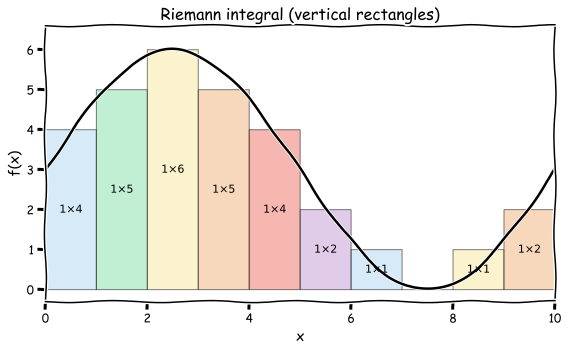

In [2]:
import numpy as np
from yoyo_plots.functions import FunctionPlot
from yoyo_plots.common import display_vector

# ── A smooth curve on an integer domain: f(x) = 3·sin(πx/5) + 3 on [0, 10]
x = np.linspace(0, 10, 500)
y = 3 * np.sin(np.pi * x / 5) + 3

# ── Riemann (vertical) rectangles with integer start/end ─────────────────
riemann_colors = ["#aed6f1", "#82e0aa", "#f9e79f", "#f0b27a", "#ec7063",
                  "#c39bd3", "#aed6f1", "#82e0aa", "#f9e79f", "#f0b27a"]
riemann_rects = [
    {"start": i, "end": i + 1, "color": riemann_colors[i], "show_label": True}
    for i in range(10)
]

plot = (FunctionPlot(
    x, y,
    xlabel="x", ylabel="f(x)",
    title="Riemann integral (vertical rectangles)",
    only_integers=True,
    rect_alpha=0.5,
    figsize=(8, 5),
)
.add_vertical_rectangles(riemann_rects))

display_vector(plot)

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

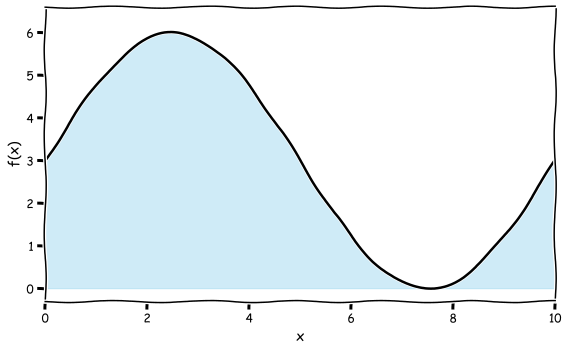

In [3]:
plot = (FunctionPlot(x, y, xlabel="x", ylabel="f(x)")
        .color_area(color="skyblue", alpha=0.4))
display_vector(plot)

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

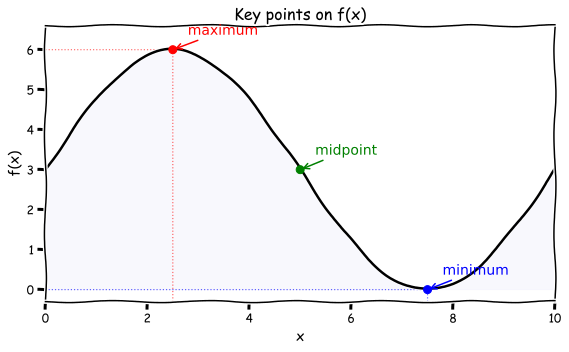

In [4]:
# Markers on the curve with labels and help lines
plot = (FunctionPlot(x, y, xlabel="x", ylabel="f(x)", title="Key points on f(x)")
        .color_area(color="lavender", alpha=0.25)
        .add_markers({
            2.5: {"color": "red", "label": "maximum", "help_line": True},
            7.5: {"color": "blue", "label": "minimum", "help_line": True},
            5:   {"color": "green", "label": "midpoint"},
        }))
display_vector(plot)

## Quantities

### Handwritten range

In [6]:
from yoyo_plots.quantities import draw_handwritten_range
from yoyo_plots.common import display_vector


fig = draw_handwritten_range(range(1, 10), rows=3)
display_vector(fig)

### Magic squares

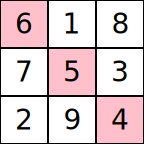

In [10]:
from yoyo_plots.common import display_vector
from yoyo_plots.quantities import draw_magic_squares_grid
from yoyo_plots.quantities import draw_magic_square

draw_magic_square(
    grid=[[6,1,8],[7,5,3],[2,9,4]],
    highlight=[(0,0),(1,1),(2,2)],  # diagonal
    highlight_color="pink"
)


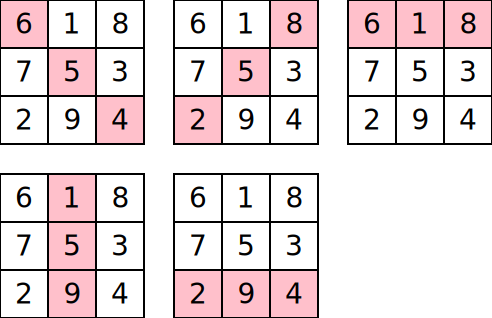

In [11]:

highlight=[
    [(0,0),(1,1),(2,2)],
    [(0,2),(1,1),(2,0)],
    [(0,0), (0, 1), (0, 2)],
    [(0, 1), (1, 1), (2, 1)],
    [(2,0), (2, 1), (2, 2)],
]


grid=[[6,1,8],[7,5,3],[2,9,4]],

# Pass all grids in a single list
grid_data = grid * len(highlight)

combined_grid = draw_magic_squares_grid(
    grids=grid_data, 
    highlights=highlight, 
    cols=3,
    spacing=30
)

display_vector(combined_grid)

### Quantities and quantities grids

In [12]:
from yoyo_plots.quantities import draw_quantity_grid

grid_specs = [dict(image="./images/alien.svg", n=1, quantity=1, font_color="black", nrows=1, image_size=0.5)]*6

draw_quantity_grid(grid_specs, cols=3)

## Operations

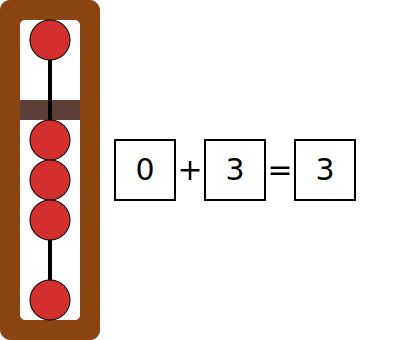

In [13]:
from yoyo_plots.operations import soroban_column

soroban_column(3, font_color="black")

In [14]:
from yoyo_plots.common import display_vector
from yoyo_plots.quantities import plot_quantity


plot_quantity("./images/elephant1.svg", 3, nrows=1, font_color="black", image_size=0.8, pixels_per_unit=80, quantity="1 x 3")

### Figural plots

In [15]:
from yoyo_plots.figural import plot_figural
from yoyo_plots.common import display_vector

fig =plot_figural("triangular", 6)
display_vector(fig)

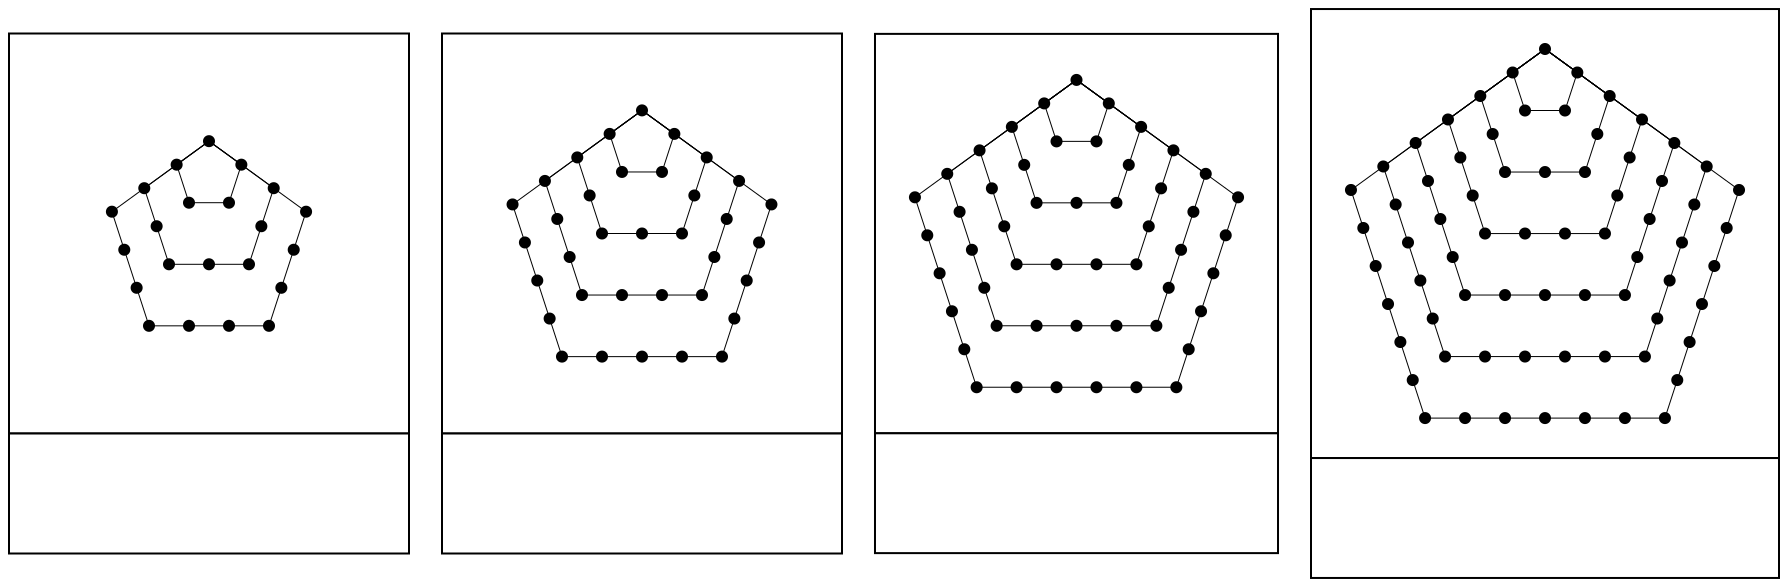

In [16]:
from yoyo_plots.common import combine_svgs, display_vector
plots = [plot_figural("pentagonal", i, box_size=5, font_color="white") for i in range(4, 8)]
svg_plot = combine_svgs(plots)
display_vector(svg_plot)

## Speed limit plots

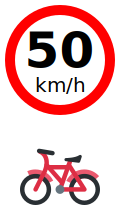

In [1]:
from yoyo_plots.speed import speed_limit
from yoyo_plots.common import combine_svgs, display_vector

speed_limit(50, "km/h", image_path="./images/1f6b2_bike.svg")

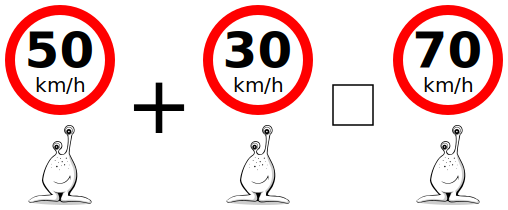

In [2]:
image = "./images/alien.svg"
s1 = speed_limit(50, "km/h", image_path=image)
s2 = speed_limit(30, "km/h", image_path=image)
s3 = speed_limit(70, "km/h", image_path=image)

combined = combine_svgs([s1, s2, s3], direction="horizontal",  separators=["+", {"type": "box", "width": 40, "height": 40}], separator_font_size=80)
display_vector(combined)

## Numbers grand hotel

This functions are used to illustrate the positional number system

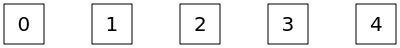

In [1]:
from yoyo_plots.common import display_vector, combine_svgs
from yoyo_plots.hotel import Label, Number

labels = [Label(values=[Number(i, "black")]) for i in range(5)]
display_vector(combine_svgs(labels, spacing=40))

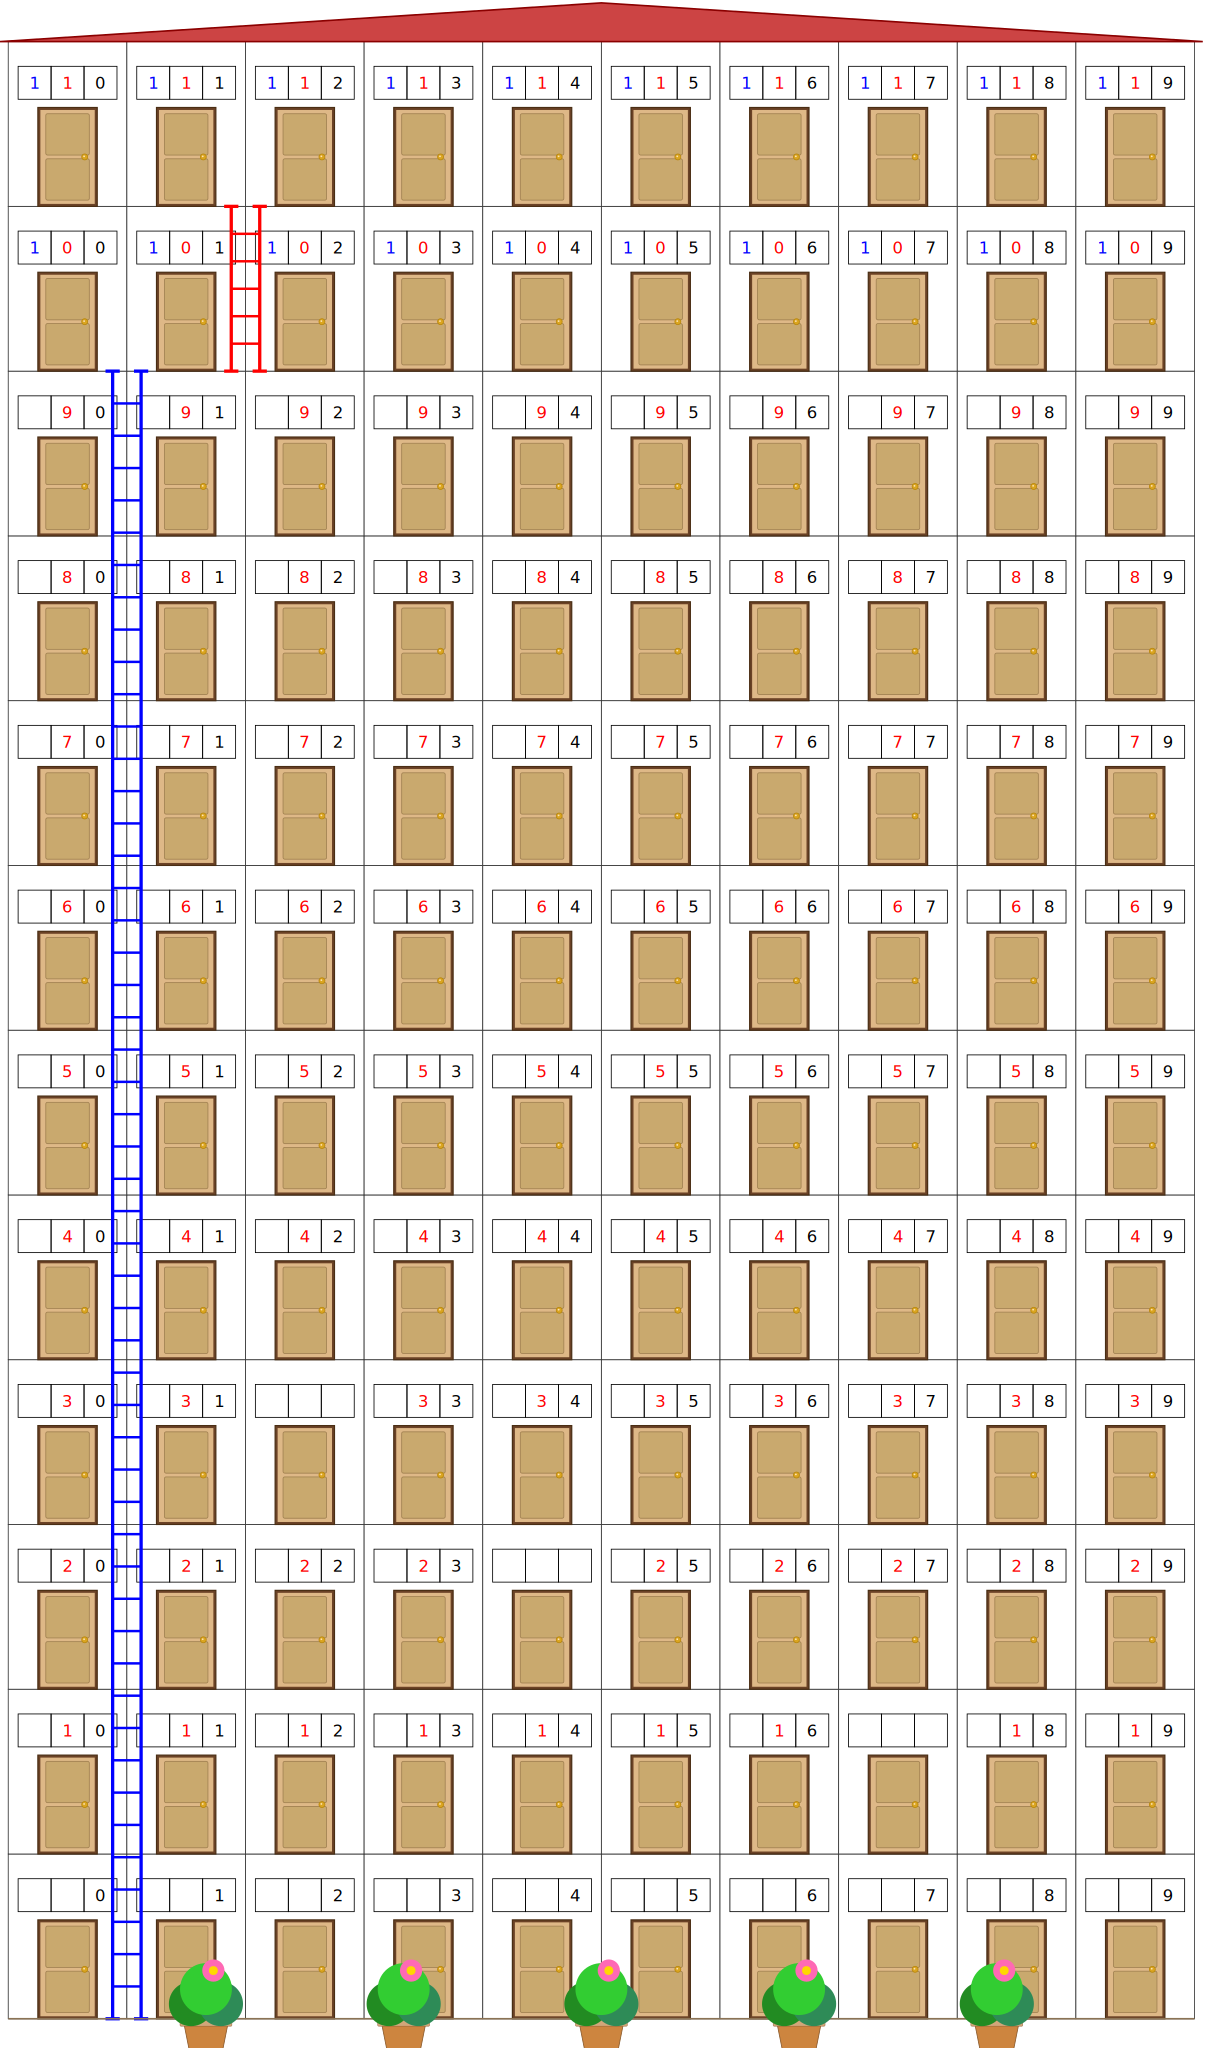

In [2]:
from yoyo_plots.hotel import Building
building = Building(10, 0, 3, 12, without_offset=False, pad_zeros=False, roof=True, plants=True, plant_scale=4.5, skip_rooms=[17, 24, 32])
# building.add_ladder(0, 0, "red")
building.add_ladder(10, 1, "red", rung_spacing=40)
building.add_ladder(0, 0, "blue", width=0.3, height=10, rung_spacing=40)
display_vector(building)

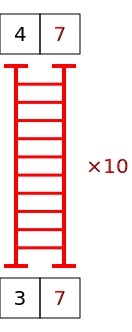

In [21]:
from yoyo_plots.hotel import Ladder, Label, Number

ladder = Ladder(x=0, y=0, width=60, height=200, color="red")
label1 = Label([Number(3, "black"), Number(7, "red")])
label2 = Label([Number(4, "black"), Number(7, "red")])

svg = ladder.to_svg(top_label=label2, bottom_label=label1, annotation="×10")
display_vector(svg)

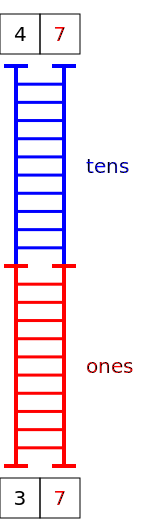

In [22]:
from yoyo_plots.hotel import draw_ladders
ladder1 = Ladder(x=0, y=0, width=60, height=200, color="red")
ladder2 = Ladder(x=0, y=0, width=60, height=200, color="blue")

svg = draw_ladders(
    [(ladder1, "ones"), (ladder2, "tens")],  # bottom first
    top_label=label2,
    bottom_label=label1,
)
display_vector(svg)

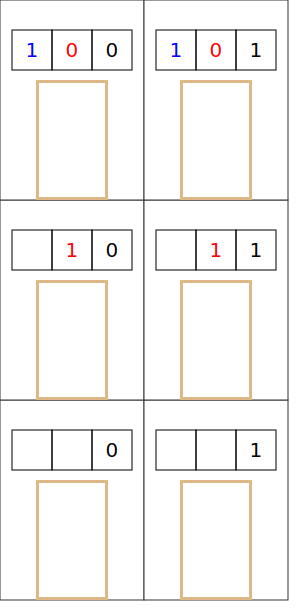

In [23]:
building = Building(0, 0, 3, 3, pad_zeros=False, base=2)
display_vector(building)

## Operations tables

- Multiplication tables
- Group tables

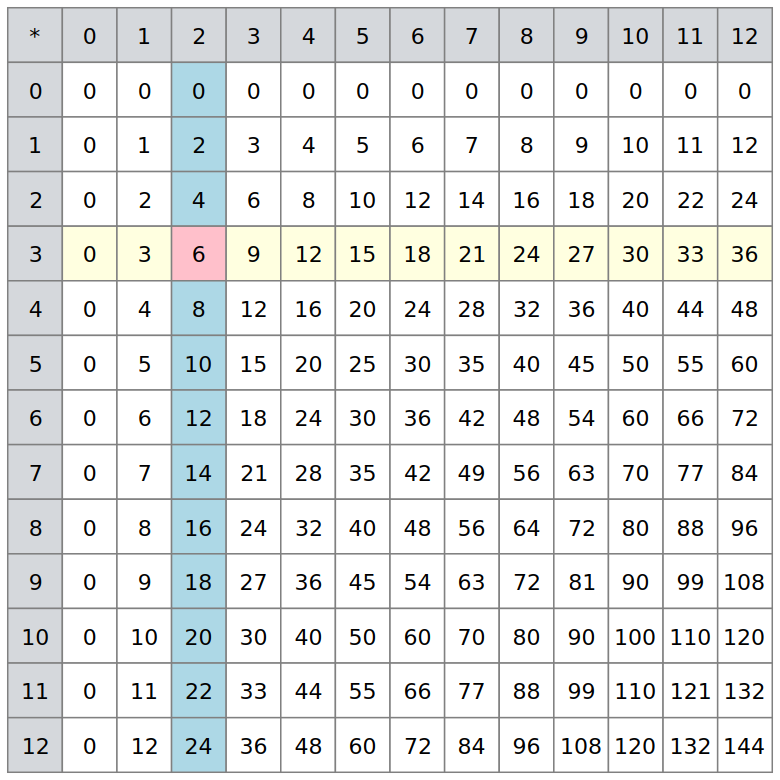

In [2]:
from yoyo_plots.multiplication import draw_operation_table
from yoyo_plots.common import display_vector

# Full 10×10 table, upper triangle only, highlight row 3, col 2, and cell (3,2)
fig = draw_operation_table(
    nrows=13, ncols=13,
    # only_rows=[3, 4, 5],
    show_upper=False,
    rows={3: "lightyellow"},
    cols={2: "lightblue"},
    operation=lambda r, c: r * c,
    operation_name="*",
    elements={(3, 2): "pink"},
)
display_vector(fig)

## Astro

Utilities to plot constellations from Sky and Telescope

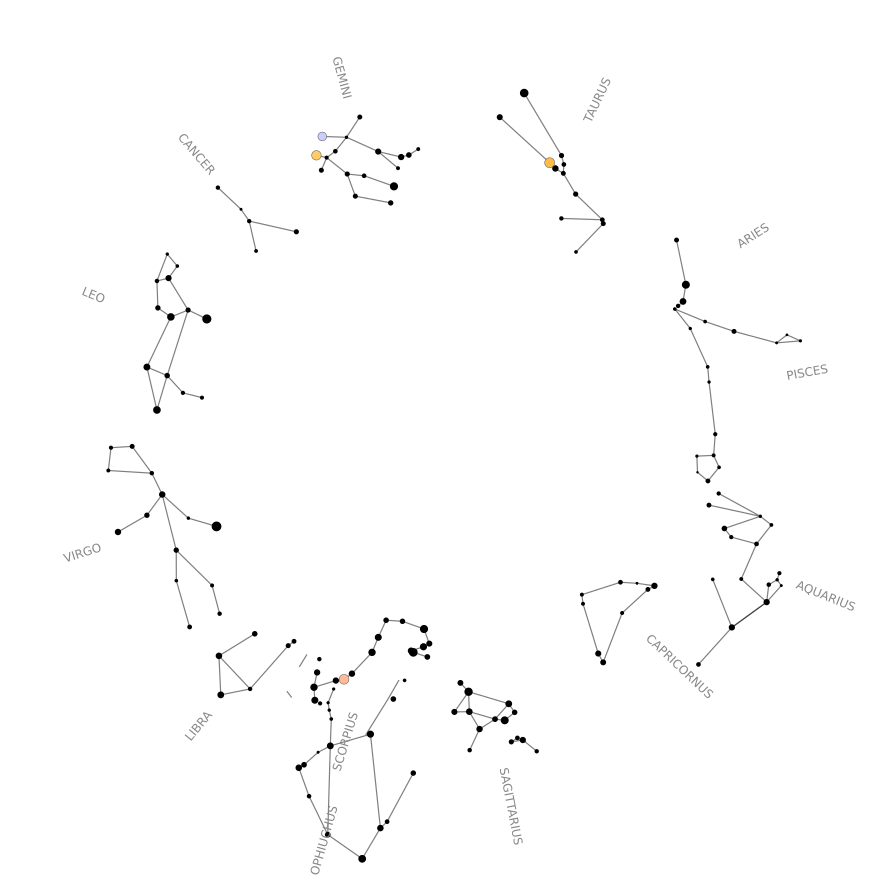

In [4]:
from yoyo_plots.astro import plot_zodiac

plot_zodiac()

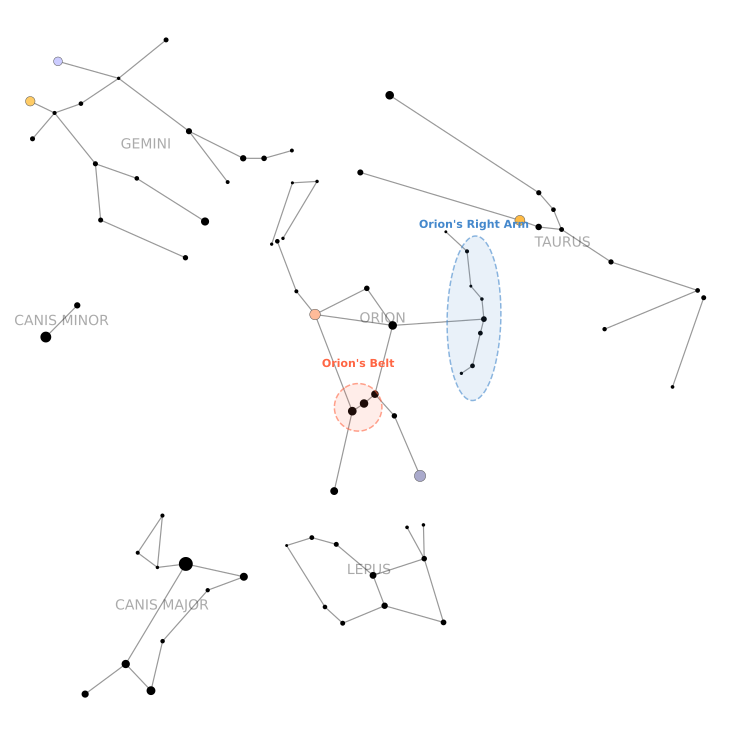

In [1]:
from yoyo_plots.astro import plot_sky

# Orion, Canis Major, Canis Minor, Taurus, Gemini, Lepus
plot_sky(
    ["Ori", "CMa", "CMi", "Tau", "Gem", "Lep"],
    show_constellations=True,
    markers={
        ("delOri", "epsOri", "zetOri"): {
            "color": "#FF6644",
            "text": "Orion's Belt",
        },
        ("pi1Ori", "pi2Ori", "pi3Ori", "pi4Ori", "pi5Ori", "pi6Ori", "omi2Ori"): {
            "color": "#4488CC",
            "text": "Orion's Right Arm",
        },
    },
)

## Geometry

Rectangles and right triangles with optional grids, dimension labels, highlights, diagonals, and Pythagorean squares.

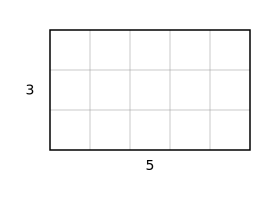

In [1]:
from yoyo_plots.geometry import draw_rectangle
from yoyo_plots.common import display_vector

# Basic rectangle with dimensions and grid
display_vector(draw_rectangle(5, 3))

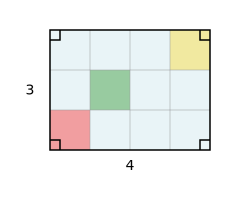

In [2]:
# Area fill, cell highlights, and right-angle marks
display_vector(draw_rectangle(
    4, 3,
    area_color="lightblue",
    cell_highlights={(0, 0): "red", (1, 1): "green", (3, 2): "gold"},
    right_angles=True,
))

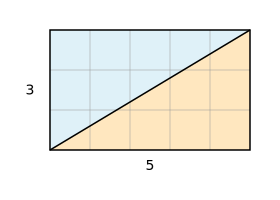

In [3]:
# Diagonal splitting the rectangle into two coloured triangles
display_vector(draw_rectangle(5, 3, diagonal=("orange", "skyblue")))

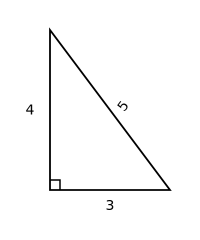

In [4]:
from yoyo_plots.geometry import draw_right_triangle

# Right triangle with dimension labels
display_vector(draw_right_triangle(3, 4))

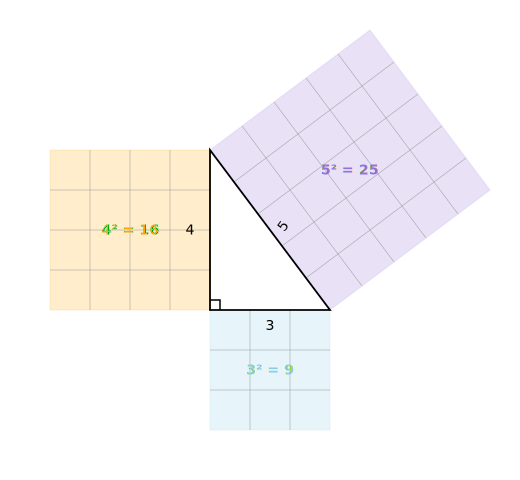

In [5]:
# Pythagorean theorem: 3² + 4² = 5²
display_vector(draw_right_triangle(
    3, 4,
    pythagorean_squares=True,
    base_color="skyblue",
    height_color="orange",
    hypotenuse_color="mediumpurple",
))

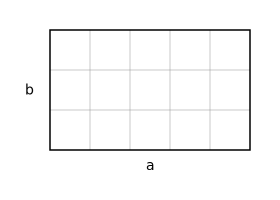

In [ ]:
# Custom dimension labels on a rectangle
display_vector(draw_rectangle(5, 3, dimension_labels=("a", "b")))

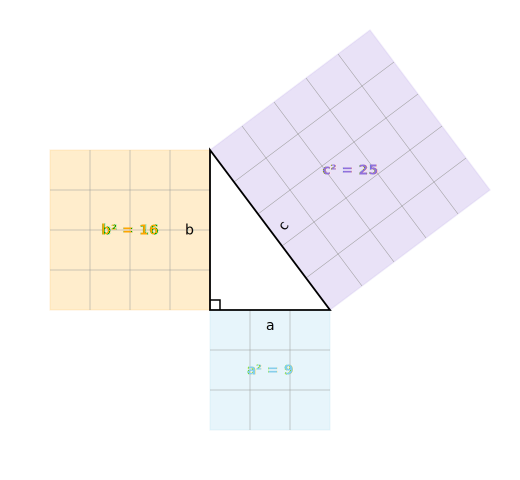

In [14]:
# Custom dimension labels on a right triangle with Pythagorean squares
display_vector(draw_right_triangle(
    3, 4,
    pythagorean_squares=True,
    base_color="skyblue",
    height_color="orange",
    hypotenuse_color="mediumpurple",
    dimension_labels=("a", "b", "c"),
))

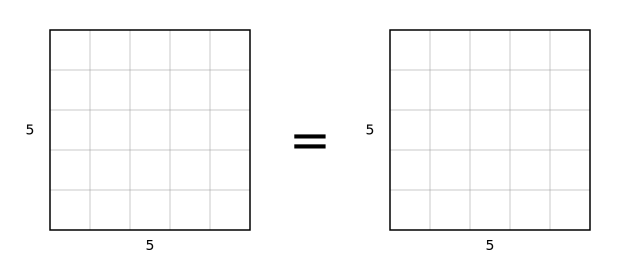

In [6]:
from yoyo_plots.geometry import draw_rectangle
from yoyo_plots.common import display_vector, combine_svgs

# Basic rectangle with dimensions and grid
f1 = draw_rectangle(5, 5)
f2 = draw_rectangle(5, 5)
c = combine_svgs([f1, f2], separators="=", separator_font_size=50)
display_vector(c)